# Training with Self-Consistency

This notebooks shows how to train an approximator with an unsupervised self-consistency loss.

In [22]:
import os
# we require tensorflow as backend due to using tensorflow_probability
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import numpy as np
import matplotlib.pyplot as plt
import bayesflow as bf
import tensorflow_probability as tfp

tfd = tfp.distributions

import bayesflow.experimental.self_consistency as sc


## Model

We use a Normal model with a Normal-Gamma prior (mean-precision parameterization):

$$\tau \sim \text{Gamma}(2, 1), \quad \mu \mid \tau \sim \mathcal{N}(0,\, \tau^{-1}), \quad y_i \mid \mu, \tau \sim \mathcal{N}(\mu,\, \tau^{-1})$$

The Normal-Gamma prior is conjugate to the normal likelihood, so the true posterior is available analytically (which we will use for validation).

In [23]:
def sim_fn():
    tau = np.random.gamma(size=1, shape=2, scale=1)
    mu = np.random.normal(size=1, scale=1.0 / np.sqrt(tau))
    y = np.random.normal(size=10, loc=mu, scale=1.0 / np.sqrt(tau))
    return dict(mu=mu, tau=tau, y=y)

simulator = bf.make_simulator(sim_fn)

Precition $\tau$ is positive only, so we will add it's log-transform to the adapter. 

In [24]:
adapter = bf.Adapter().log("tau")

## Datasets

Here we have two datasets:
- **labeled**: simulated data with known parameters `(mu, tau)` and the observations `y` — used for standard posterior training.
- **unlabeled**: empirical observations `y` only, drawn from any generating model. Here, the unlabeled data have high variance (low precision), and are therefore out-of-distribution wrt the approximated model.

In principle, the `SemiSupervisedApproximator` can be trained on any number of datasets. This allows, for example, separate supervised training of a posterior and likelihood network (when the likelihood is not analytic).

In [25]:
dataset_labeled = bf.OnlineDataset(
    simulator=simulator,
    adapter=adapter,
    batch_size=64, num_batches=50)

In [26]:
dataset_unlabeled = bf.OfflineDataset(
    data=dict(y=np.random.normal(loc=0.0, scale=10, size=(32, 10))),
    adapter=adapter,
    batch_size=8
)

We wrap all datasets that we use for training into one dataset class. Each batch will be a dictionary containing batches from individual data sets.

In [27]:
dataset = sc.MultiDataset(labeled=dataset_labeled, unlabeled=dataset_unlabeled)

print(dataset[0].keys())
print(dataset[0]["labeled"].keys())
print(dataset[0]["unlabeled"].keys())

dict_keys(['labeled', 'unlabeled'])
dict_keys(['mu', 'tau', 'y'])
dict_keys(['y'])


## Prior and likelihood

The SC loss needs access to the prior and likelihood log-densities.

Here we define prior and likelihood analytically. Alternatively, they can be also approximated.

Note that these functions receive parameters in the **original** (un-transformed) space. Therefore, you do not need to transform $\tau$ manually from the log space. However, the evaluation of log-densities is currently not auto-batched, so you have to take care of batching yourself, and you have to define the log_prob with keras tensor operations (so that they can be evaluated during training). Here, we use tensorflow probability distributions, which help us do that.

In [28]:
def prior_log_prob(mu, tau, **kwargs):
    tau_log_prob = tfd.Gamma(concentration=2.0, rate=1.0).log_prob(tau)
    mu_log_prob = tfd.Normal(loc=0.0, scale=1.0 / keras.ops.sqrt(tau)).log_prob(mu)
    return mu_log_prob + tau_log_prob

In [29]:
def likelihood_log_prob(y, mu, tau, **kwargs):
    y_log_prob = tfd.Normal(loc=mu, scale=1.0 / keras.ops.sqrt(tau)).log_prob(y)
    return keras.ops.sum(y_log_prob, axis=1)

## Posterior approximator

A `ContinuousApproximator` with a `CouplingFlow` inference network and a `DeepSet` summary network. Notice that we specify an additional adapter for the approximator itself. This local adapter will be run after the global adapter that transforms tau. The global adapter takes care of operations that are needed for all approximators, whereas local adapters like here reshape data as needed for the specific approximator. Here, the adapter specifies that `mu` and `tau` are the inference variables and `y` is the summary variables - hence, specifying a posterior network.

In [30]:
posterior = bf.ContinuousApproximator(
    inference_network=bf.networks.CouplingFlow(),
    summary_network=bf.networks.DeepSet(),
    adapter=bf.Adapter().as_set("y").concatenate(["mu", "tau"], into="inference_variables").rename("y", "summary_variables"),
    #standardize=None
)

The main approximator wraps all approximator in one object. Here we have analytic prior and likelihood, and approximate posterior.

In [31]:
approximator = sc.SemiSupervisedApproximator(
    approximators={
        "prior": prior_log_prob,
        "likelihood": likelihood_log_prob,
        "posterior": posterior,
    },
    adapter=adapter,
)

Before training, we will also generate some synthetic data for evaluation. Here the data is generated with a high variance (low precision). The data is therefore out-of-distribution wrt the simulator, but not out-of-distribution wrt the unlabeled data.

In [32]:
eval_data = dict(y=np.random.normal(loc=0.0, scale=10, size=(1, 10)))
samples = dict()

## Phase 1: Supervised training only

First we can train the posterior on labeled (simulated) data only. We do this by specifying which approximator (here, `posterior`) train on which data set (here: `labeled`), using the approximator-specific metrics.

In [33]:
schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=100 * dataset.num_batches
)
optimizer = keras.optimizers.Adam(schedule, clipvalue=1.0)

approximator.compile(
    optimizer,
    approximator_metrics={"labeled": ["posterior"]}
)

history = approximator.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - labeled/posterior/loss: 1.4732 - loss: 1.4732
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - labeled/posterior/loss: 1.0490 - loss: 1.0490
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/posterior/loss: 0.9921 - loss: 0.9921
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - labeled/posterior/loss: 0.9810 - loss: 0.9810
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - labeled/posterior/loss: 0.9904 - loss: 0.9904
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - labeled/posterior/loss: 0.9462 - loss: 0.9462
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - labeled/posterior/loss: 0.9298 - loss: 0.9298
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - labeled/posterior/loss: 0.8714 - loss: 0.8714
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - labeled/posterior/loss: 0.8581 - loss: 0.8581
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - labeled/posterior/loss: 0.9137 - loss: 0.9137


In [34]:
samples["No SC"] = approximator.sample(approximator="posterior", num_samples=1000, conditions=eval_data)

Sampling: 100%|██████████| 1/1 [00:00<00:00, 14.44batch/s]


## Phase 2: Self-consistency training

Add the SC loss on unlabeled data and continue training. The SC loss enforces Bayes' theorem:

$$\log p(y) = \log p(\mu, \tau) + \log p(y \mid \mu, \tau) - \log q(\mu, \tau \mid y)$$

should have zero variance across parameter samples, which drives the posterior toward consistency with the prior and likelihood.

We add the SC loss by specifying that composite metrics (metrics that require a combination of multiple approximators) on the `unlabeled` data set.

In [35]:
approximator.compile(
    optimizer,
    approximator_metrics={"labeled": ["posterior"]},
    composite_metrics={
        "unlabeled": sc.SelfConsistencyLoss(num_samples=16)
    }
)

history = approximator.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - labeled/posterior/loss: 2.6377 - loss: 162.0834 - unlabeled/self-consistency/loss: 159.4457
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - labeled/posterior/loss: 1.3939 - loss: 3.6528 - unlabeled/self-consistency/loss: 2.2588
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - labeled/posterior/loss: 1.1721 - loss: 2.2405 - unlabeled/self-consistency/loss: 1.0684
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - labeled/posterior/loss: 1.0490 - loss: 1.6389 - unlabeled/self-consistency/loss: 0.5899
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - labeled/posterior/loss: 0.9783 - loss: 1.3397 - unlabeled/self-consistency/loss: 0.3613
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - labeled/posterior/loss: 0.9051 - loss: 1.1018 - unlabeled/self-consistency/loss: 0.1968
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - labeled/posterior/loss: 0.9255 - loss: 1.0655 - unlabeled/self-consistency/loss: 0.1400
Epoch 8/

In [36]:
samples["SC"] = approximator.sample(approximator="posterior", num_samples=1000, conditions=eval_data)

Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.58batch/s]


## Evaluation

Now we compare the results from simulation-based training and self-consistency training.

The Normal-Gamma posterior is available in closed form, so we will compare posterior samples from both training methods to samples from this reference

In [37]:
def sample_posterior(y, n_samples, mu0=0.0, kappa=1.0, shape=2.0, scale=1.0):
    y = y.flatten()
    n = len(y)
    ybar = np.mean(y)
    S = np.sum((y - ybar) ** 2)

    kappa_n = kappa + n
    mu_n = (kappa * mu0 + n * ybar) / kappa_n
    shape_n = shape + n / 2
    rate_n = 1 / scale + 0.5 * S + (kappa * n / (2 * kappa_n)) * (ybar - mu0) ** 2

    tau = np.random.gamma(shape=shape_n, scale=1.0 / rate_n, size=n_samples)
    mu = np.random.normal(loc=mu_n, scale=1.0 / np.sqrt(kappa_n * tau), size=n_samples)

    return dict(mu=mu, tau=tau)


samples["Reference"] = sample_posterior(eval_data["y"], n_samples=1000)

Samples from the approximator trained with the SC loss are much more similar to the reference than pure simulation-based training.

Text(0, 0.5, '$\\tau$')

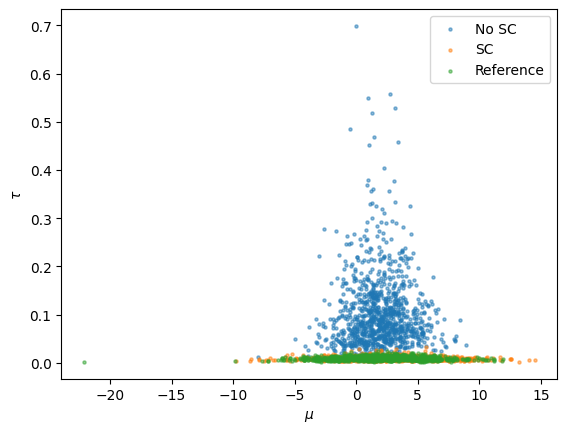

In [38]:
for k, s in samples.items():
    plt.scatter(s["mu"].flatten(), s["tau"].flatten(), label=k, alpha=0.5, s=5.0)
f=plt.legend()
plt.xlabel("$\\mu$")
plt.ylabel("$\\tau$")

## Approximate posterior and likelihood

Prior and likelihood do not need to be analytic, and can be also approximated. The trick is to specify multiple approximators that take different arguments are inference variables/summary variables/inference conditions.

Here is how we would approximate both posterior and likelihood (NPLE) and train them with self consistency.

First, we define the posterior approximator as previously.

In [39]:
posterior_approx = bf.ContinuousApproximator(
    inference_network = bf.networks.CouplingFlow(),
    summary_network = bf.networks.DeepSet(),
    adapter = bf.Adapter().as_set("y").concatenate(["mu", "tau"], into="inference_variables").rename("y", "summary_variables")
)


Then, define a likelihood approximator. Thi approximator predicts the distribution of data `y` given parameters `mu` and `tau`. Therefore, the likelihood adapter uses `mu` and `tau` as inference conditions, and `y` as inference variables.

In [40]:
likelihood_approx = bf.ContinuousApproximator(
    inference_network = bf.networks.CouplingFlow(),
    summary_network = None,
    adapter = bf.Adapter().concatenate(["mu", "tau"], into="inference_conditions").rename("y", "inference_variables")
)

In [41]:
approximator_nple = sc.SemiSupervisedApproximator(
    approximators = {
        "prior": prior_log_prob,
        "likelihood": likelihood_approx,
        "posterior": posterior_approx
    },
    adapter=adapter
)

Typically, it's a good idea to pretrain the networks with pure simulation-based training. Now we need to specify that both posterior and likelihood approximators need to be trained with their own metrics, evaluated on the labeled data set.

In [42]:
approximator_nple.compile(
  keras.optimizers.Adam(schedule, clipvalue=1.0),
  approximator_metrics = {"labeled": ["posterior", "likelihood"]}
)

history = approximator_nple.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - labeled/likelihood/loss: 10.6636 - labeled/posterior/loss: 1.5767 - loss: 12.2403
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - labeled/likelihood/loss: 8.8118 - labeled/posterior/loss: 1.0511 - loss: 9.8629
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - labeled/likelihood/loss: 8.8119 - labeled/posterior/loss: 1.0232 - loss: 9.8352
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/likelihood/loss: 9.0889 - labeled/posterior/loss: 1.0402 - loss: 10.1291
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - labeled/likelihood/loss: 8.8829 - labeled/posterior/loss: 0.9757 - loss: 9.8586
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/likelihood/loss: 8.8761 - labeled/posterior/loss: 0.9126 - loss: 9.7887
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/likelihood/loss: 9.0106 - labeled/posterior/loss: 0.9677 - loss: 9.9783
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/like

After that, we can do SC training. Note that by default, only the posterior network is trained with self-consistency. You can change that using the argument `gradient` in `sc.SelfConsistencyLoss`.

In [43]:
approximator_nple.compile(
  keras.optimizers.Adam(schedule, clipvalue=1.0),
  approximator_metrics = {"labeled": ["posterior", "likelihood"]},
  composite_metrics = {
      "unlabeled": sc.SelfConsistencyLoss(num_samples=16)
  }
)

history = approximator_nple.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - labeled/likelihood/loss: 8.8349 - labeled/posterior/loss: 1.0943 - loss: 24.7546 - unlabeled/self-consistency/loss: 14.8253
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - labeled/likelihood/loss: 8.7458 - labeled/posterior/loss: 0.9589 - loss: 11.7608 - unlabeled/self-consistency/loss: 2.0561
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - labeled/likelihood/loss: 8.7236 - labeled/posterior/loss: 0.9119 - loss: 11.2891 - unlabeled/self-consistency/loss: 1.6536
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - labeled/likelihood/loss: 8.7514 - labeled/posterior/loss: 0.9385 - loss: 10.6363 - unlabeled/self-consistency/loss: 0.9463
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - labeled/likelihood/loss: 8.8304 - labeled/posterior/loss: 0.9733 - loss: 10.9514 - unlabeled/self-consistency/loss: 1.1476
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - labeled/likelihood/loss: 8.7962 - labeled/posterior/loss: 0.9691 